## imports

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Carpeta raíz del proyecto

In [2]:
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("No pude encontrar la raíz del proyecto.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
WORKING_DIR = DATA_DIR / "working"
MANIFESTS_DIR = DATA_DIR / "manifests"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("WORKING_DIR:", WORKING_DIR)
print("MANIFESTS_DIR:", MANIFESTS_DIR)

PROJECT_ROOT: /home/uaodeepia/luis/proyecto_analitica2
DATA_DIR: /home/uaodeepia/luis/proyecto_analitica2/data
WORKING_DIR: /home/uaodeepia/luis/proyecto_analitica2/data/working
MANIFESTS_DIR: /home/uaodeepia/luis/proyecto_analitica2/data/manifests


## manifiesto y subset large


In [3]:
manifest_path = MANIFESTS_DIR / "manifest_isic_master.csv"
subset_path = WORKING_DIR / "isic" / "subsets" / "isic_subset_large.csv"

manifest_df = pd.read_csv(manifest_path)
subset_df = pd.read_csv(subset_path)

print("manifest_df:", manifest_df.shape)
print("subset_df:", subset_df.shape)

print("\nConteo por split:")
print(subset_df["split_final"].value_counts())

subset_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/home/uaodeepia/luis/proyecto_analitica2/data/working/isic/subsets/isic_subset_large.csv'

## definir clases y mapa de etiquetas

In [4]:
class_names = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC", "UNK"]

label_to_idx = {label: i for i, label in enumerate(class_names)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

print("Clases:")
print(class_names)
print("\nNúmero de clases:", len(class_names))

Clases:
['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

Número de clases: 9


## guardar label map

In [5]:
label_map_dir = WORKING_DIR / "isic" / "meta"
label_map_dir.mkdir(parents=True, exist_ok=True)

label_map_path = label_map_dir / "isic_label_to_idx.json"
with open(label_map_path, "w", encoding="utf-8") as f:
    json.dump(label_to_idx, f, ensure_ascii=False, indent=2)

print("Label map guardado en:", label_map_path)

Label map guardado en: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/isic/meta/isic_label_to_idx.json


## validar target_label

In [6]:
print("Distribución de target_label en subset:")
print(subset_df["target_label"].value_counts())

invalid_labels = subset_df[~subset_df["target_label"].isin(class_names)]
print("\nFilas con labels inválidas:", len(invalid_labels))

Distribución de target_label en subset:
target_label
NV      6581
MEL     2281
BCC     1697
BKL     1386
AK       492
SCC      315
VASC     129
DF       119
Name: count, dtype: int64

Filas con labels inválidas: 0


## separar train / val / test

In [7]:
train_df = subset_df[subset_df["split_final"] == "train"].copy()
val_df = subset_df[subset_df["split_final"] == "val"].copy()
test_df = subset_df[subset_df["split_final"] == "test"].copy()

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (10000, 23)
val: (1500, 23)
test: (1500, 23)


## rutas faltantes

In [8]:
def count_missing_files(df):
    return (~df["file_path"].apply(lambda x: Path(x).exists())).sum()

print("Faltantes en train:", count_missing_files(train_df))
print("Faltantes en val:", count_missing_files(val_df))
print("Faltantes en test:", count_missing_files(test_df))

Faltantes en train: 0
Faltantes en val: 0
Faltantes en test: 0


## transforms básicos

In [9]:
IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## Dataset de ISIC

In [10]:
class ISICDataset(Dataset):
    def __init__(self, dataframe, label_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.label_to_idx = label_to_idx
        self.transform = transform

        required_cols = ["file_path", "target_label", "split_final", "image_name"]
        for col in required_cols:
            if col not in self.df.columns:
                raise ValueError(f"Falta la columna requerida: {col}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = Path(row["file_path"])
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        target_label = row["target_label"]
        target_idx = self.label_to_idx[target_label]

        return {
            "image": image,
            "target": torch.tensor(target_idx, dtype=torch.long),
            "image_name": row["image_name"],
            "file_path": str(image_path),
            "target_label": target_label,
            "split_final": row["split_final"],
        }

## Creacion de dataset

In [11]:
train_dataset = ISICDataset(train_df, label_to_idx, transform=train_transform)
val_dataset = ISICDataset(val_df, label_to_idx, transform=eval_transform)
test_dataset = ISICDataset(test_df, label_to_idx, transform=eval_transform)

print("Tamaños de datasets:")
print("train:", len(train_dataset))
print("val:", len(val_dataset))
print("test:", len(test_dataset))

Tamaños de datasets:
train: 10000
val: 1500
test: 1500


## Dataloaders

In [12]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)

print("Dataloaders creados correctamente.")
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

Dataloaders creados correctamente.
train batches: 313
val batches: 47
test batches: 47


## inspección de una muestra

In [13]:
sample = train_dataset[0]

print("Claves:", sample.keys())
print("Shape imagen:", sample["image"].shape)
print("Target idx:", sample["target"])
print("Target label:", sample["target_label"])
print("image_name:", sample["image_name"])
print("split_final:", sample["split_final"])

Claves: dict_keys(['image', 'target', 'image_name', 'file_path', 'target_label', 'split_final'])
Shape imagen: torch.Size([3, 224, 224])
Target idx: tensor(2)
Target label: BCC
image_name: ISIC_0067679
split_final: train


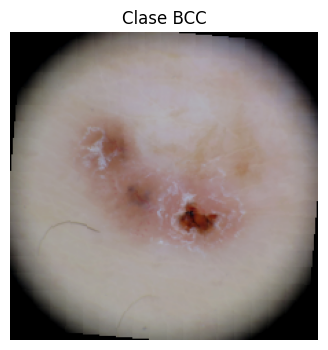

In [14]:
def denormalize_tensor(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (img_tensor.cpu() * std) + mean

img = sample["image"]
img_vis = denormalize_tensor(img).clamp(0, 1)

import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.imshow(np.transpose(img_vis.numpy(), (1, 2, 0)))
plt.title(f"Clase {sample['target_label']}")
plt.axis("off")
plt.show()

## inspección de un batch

In [15]:
batch = next(iter(train_loader))

print("Tipo de batch:", type(batch))
print("Shape batch imágenes:", batch["image"].shape)
print("Shape batch targets:", batch["target"].shape)
print("Primeros target labels:", batch["target_label"][:5])
print("Primeros image_name:", batch["image_name"][:5])

Tipo de batch: <class 'dict'>
Shape batch imágenes: torch.Size([32, 3, 224, 224])
Shape batch targets: torch.Size([32])
Primeros target labels: ['NV', 'SCC', 'MEL', 'BCC', 'MEL']
Primeros image_name: ['ISIC_0033043', 'ISIC_0062479', 'ISIC_0073038', 'ISIC_0032092', 'ISIC_0055404']
